## Importación

[ 5.96627073  3.93890591  3.67991027  3.67995362 10.84321348  7.00798283
  3.09296841  6.13487182  5.08539434  0.78875949]


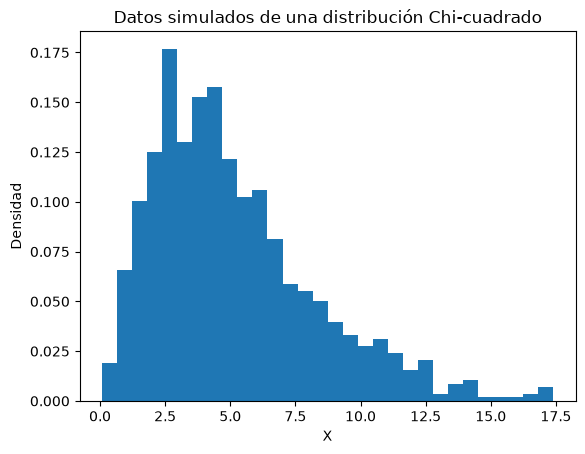

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

np.random.seed(42)

datos = chi2.rvs(df=5, size=1000)

print(datos[:10])

plt.hist(datos, bins=30, density=True)

plt.xlabel("X")
plt.ylabel("Densidad")
plt.title("Datos simulados de una distribución Chi-cuadrado")
plt.show()

## Parámetro de la distribución

La distribución chi-cuadrado tiene como parámetro principal:

* ```df``` → grados de libertad

In [2]:
df = 5

A diferencia de la normal, la distribución chi-cuadrado no es simétrica y solo puede tomar valores:

$$ X \geq 0 $$

Podemos crear una distribución:

In [3]:
dist = chi2(df=df)

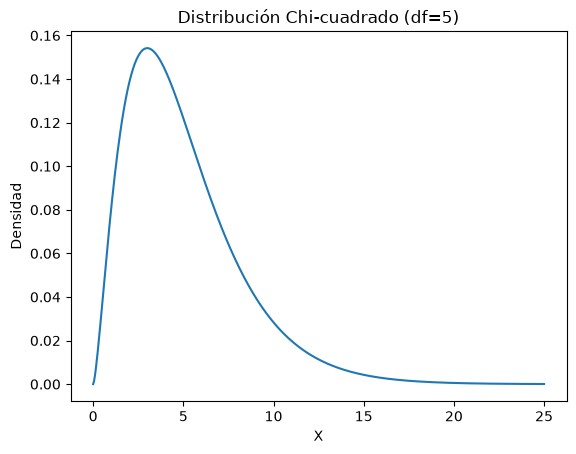

In [4]:
x = np.linspace(0, 25, 500)

pdf = chi2.pdf(x, df=df)

plt.plot(x, pdf)
plt.xlabel("X")
plt.ylabel("Densidad")
plt.title(f"Distribución Chi-cuadrado (df={df})")
plt.show()

## PDF — función de densidad

```pdf()``` devuelve la densidad en un determinado valor de ```X```.

In [5]:
x_value = 5

density = chi2.pdf(x_value, df=df)

print(density)

0.12204152134938738


```pdf()``` no representa directamente la probabilidad de obtener exactamente ```X = 5```.

En una variable continua, la probabilidad de un punto exacto es 0. ```pdf()``` representa densidad.

## CDF - probabilidad acumulada
```cdf()``` calcula:

$$ P(X \leq x) $$

Por ejemplo:

In [6]:
x_value = 5

p = chi2.cdf(x_value, df=df)

print(p)

0.584119813004492


Esto responde:

- ¿Cuál es la probabilidad de obtener un valor de chi-cuadrado menor o igual a 5?

### Probabilidad de obtener un valor mayor

Por ejemplo:

¿Cuál es la probabilidad de obtener un valor mayor a 10?

In [7]:
x_value = 10

p_right = 1 - chi2.cdf(x_value, df=df)

print(p_right)

0.07523524614651222


Esto representa:

$$ P(X > 10) $$

### Probabilidad entre dos valores
Por ejemplo:

¿Cuál es la probabilidad de que X esté entre 3 y 10?

In [8]:
p = chi2.cdf(10, df=df) - chi2.cdf(3, df=df)

print(p)

0.6247505897321154


Representa:

$$ P(3 \leq X \leq 10) $$

## PPF - obtener un valor crítico
Aquí hacemos el proceso inverso de ```cdf()```.

In [9]:
probabilidad = 0.95

chi_square_critical = chi2.ppf(probabilidad, df=df)

print(chi_square_critical)

11.070497693516351


Esto responde:

- ¿Qué valor de chi-cuadrado deja el 95 % del área a la izquierda?

Matemáticamente:

$$ P(X\leq\chi^2_{crítico})=0.95 $$

## Valor crítico para α = 0.05

In [10]:
alpha = 0.05

chi_square_critical = chi2.ppf(1 - alpha, df=df)

print(chi_square_critical)

11.070497693516351


¿Por qué 1 - alpha?

Porque en una prueba chi-cuadrado típica la región de rechazo está en la cola derecha:

$$ P(X>\chi^2_{crítico})=\alpha $$

Por tanto:

$$ P(X\leq\chi^2_{crítico})=1-\alpha $$

## P-value a partir de un estadístico chi-cuadrado

Supongamos que después de realizar una prueba obtienes:

In [12]:
chi_square_calculated = 12.5
df = 5

Puedes calcular el p-value:

In [13]:
p_value = chi2.sf(chi_square_calculated, df=df)

print(p_value)

0.028543123326167485


Aquí:

$$ p\text{-value}=P(\chi^2\geq12.5) $$

Esto es muy importante para diferenciar:

```chi2.ppf()```\
      ```↓```\
```obtiene el valor crítico```

```chi2.sf()```\
      ```↓```
```obtiene el p-value a partir del
estadístico calculado```

## Comparar chi-cuadrado calculado y crítico

In [14]:
chi_square_calculated = 12.5
alpha = 0.05
df = 5

chi_square_critical = chi2.ppf(1 - alpha, df=df)

print("Chi-cuadrado calculado:", chi_square_calculated)
print("Chi-cuadrado crítico:", chi_square_critical)

Chi-cuadrado calculado: 12.5
Chi-cuadrado crítico: 11.070497693516351


Después puedes tomar la decisión:

In [15]:
if chi_square_calculated > chi_square_critical:
    print("Se rechaza H0")
else:
    print("No se rechaza H0")

Se rechaza H0


La lógica es:

$$ \chi^2_{calculado}>\chi^2_{crítico} \Rightarrow \text{rechazar }H_0 $$

## Efecto de los grados de libertad

Esta sección es muy útil para entender la distribución.

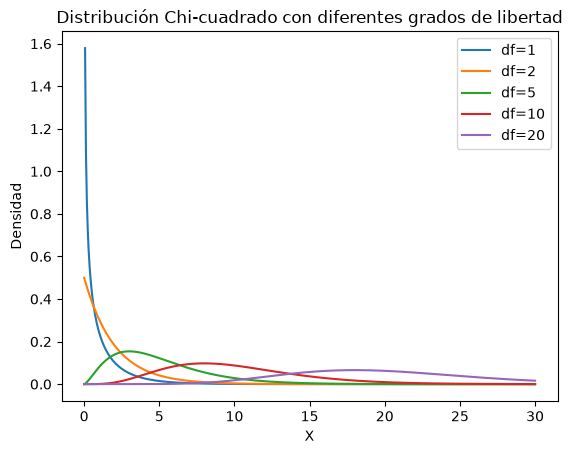

In [16]:
x = np.linspace(0, 30, 500)

for df in [1, 2, 5, 10, 20]:
    plt.plot(x, chi2.pdf(x, df=df), label=f"df={df}")

plt.xlabel("X")
plt.ylabel("Densidad")
plt.title("Distribución Chi-cuadrado con diferentes grados de libertad")
plt.legend()
plt.show()

Se puede observar que al aumentar ```df```, la distribución cambia de forma y se vuelve menos sesgada.

Media y varianza teóricas

Para una distribución chi-cuadrado:

$$ E(X)=df $$

y

$$ Var(X)=2df $$

In [17]:
df = 5

mean = chi2.mean(df)
variance = chi2.var(df)

print("Media:", mean)
print("Varianza:", variance)

Media: 5.0
Varianza: 10.0
